# CABR

In [1]:
# --------------------------------------------------------
# Import packages
# --------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from diffPLOG2TROE.parametrization import CABR

- Equations
    > $k_f \: (T, P) = k_{0} \left(\dfrac{1}{1+P_{r}}\right)F(T, P_r) $
    >
    > - $P_r$ is the reduce pressure computed as follow: $P_r = \dfrac{k_{0}[M]}{k_{\infty}}$
    > - $[M]$ is the concentration of the mixture, possibly including enhanced third-body efficiencies.
    > - $k_0$ and $k_{\infty}$ are the low pressure and high pressure limits of the rate constant computed as a classic Arrhenius constant.
    >
    > - $F(T, P_r)$ is the blending function that depending on different formalism is computed in different ways.

## Lindemann
- Equations
    > $F = 1$
- CHEMKIN representation
    >```
    > CH3 + CH3(+M) = H + C2H5(+M)       4.989E+12  0.099  10600.  ! Stewart
    >  HIGH /                            3.800E-07  4.838  7710. / ! Chemically activated reaction
    >```
- Internal representation
    >```python
    >lindemann_constant = {
    >    "name": "CH3+CH3(+M)=H+C2H5(+M)",
    >    "type": "cabr",
    >    "cabr-type": "lindemann",
    >    "rate-constant": {
    >        "lpl-coefficients": [4.989E+12, 0.099, 10600.],
    >        "hpl-coefficients": [3.80e-7, 4.838, 7710.],
    >    }
    >}

In [2]:
# --------------------------------------------------------
# Dictionary initialization
# --------------------------------------------------------
lindemann_constant = {
   "name": "CH3+CH3(+M)=H+C2H5(+M)",
   "type": "cabr",
   "cabr-type": "lindemann",
   "rate-constant": {
       "lpl-coefficients": [4.989E+12, 0.099, 10600.],
       "hpl-coefficients": [3.80e-7, 4.838, 7710.],
   }
}
rate_constant = CABR(lindemann_constant)

# --------------------------------------------------------
# Direct parameters initialization
# --------------------------------------------------------
rate_constant = CABR(
    name="CH3+CH3(+M)=H+C2H5(+M)",
    lpl_params=[4.989E+12, 0.099, 10600.],
    hpl_params=[3.80e-7, 4.838, 7710.],
    cabr_type="lindemann"
)

## Kinetic constant computation

After initializing the rate constant correctly, we gain access to the methods specific to the FallOff object, including the calculation of the kinetic constant across different temperature and pressure ranges.

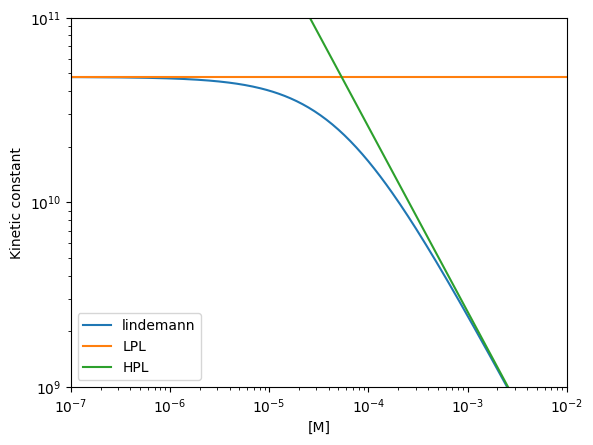

In [3]:
P_range = jnp.logspace(jnp.log10(0.001), jnp.log10(1000), 300)

hpl = rate_constant.hpl.kinetic_constant(jnp.array([1000]*300)) # Compute the value of the HPL
lpl = rate_constant.lpl.kinetic_constant(jnp.array([1000]*300)) # Compute the value of the LPL
k_lindemann, M = rate_constant.kinetic_constant(1000, P_range) # Kinetic constant here returns also M just to ease subsequent plotting stuff

fig, ax = plt.subplots()
ax.plot(M, k_lindemann, label="lindemann")
ax.plot(M, lpl, label="LPL")
ax.plot(M, hpl/M, label="HPL")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1e-7, 0.01])
ax.set_ylim([1e9, 1e11])
ax.set_xlabel("[M]")
ax.set_ylabel("Kinetic constant")
ax.legend()
plt.show()

## TROE

### TODO

In [4]:
# --------------------------------------------------------
# Dictionary initialization
# --------------------------------------------------------

# --------------------------------------------------------
# Parameters initialization
# --------------------------------------------------------

## Kinetic constant computation

## SRI
- Equations
    > $F = d\left[a\times exp\left(-b/T\right) + exp\left(-T/c\right)\right]^{\chi} T^{e}$
    > 
    > $\chi = \dfrac{1}{1 + log_{10}^{2}P_{r}}$
- CHEMKIN representation
    >```
    > CH3 + CH3(+M) = H + C2H5(+M)       4.989E+12  0.099  10600.  ! Stewart
    >  HIGH /                            3.800E-07  4.838  7710. / ! Chemically activated reaction
    > SRI   / 1.641 4334 2725                                    /
    >```
- Internal representation
    >```python
    >sri_constant = {
    >    "name": "CH3+CH3(+M)=H+C2H5(+M)",
    >    "type": "cabr",
    >    "cabr-type": "sri",
    >    "rate-constant": {
    >        "lpl-coefficients": [4.989E+12, 0.099, 10600.],
    >        "hpl-coefficients": [3.80e-7, 4.838, 7710.],
    >        "sri-coefficients": [1.641, 4334., 2725., 1., 0.],
    >    },
    >}

In [5]:
# --------------------------------------------------------
# Dictionary initialization
# --------------------------------------------------------
sri_constant = {
   "name": "CH3+CH3(+M)=H+C2H5(+M)",
   "type": "cabr",
   "cabr-type": "sri",
   "rate-constant": {
       "lpl-coefficients": [4.989E+12, 0.099, 10600.],
       "hpl-coefficients": [3.80e-7, 4.838, 7710.],
       "cabr-coefficients": [1.641, 4334., 2725.],
   },
}
rate_constant = CABR(sri_constant)

# --------------------------------------------------------
# Parameters initialization
# --------------------------------------------------------
rate_constant = CABR(
    name="CH3+CH3(+M)=H+C2H5(+M)",
    lpl_params=[4.989E+12, 0.099, 10600.],
    hpl_params=[3.80e-7, 4.838, 7710.],
    cabr_params=[1.641, 4334., 2725.],
    cabr_type="sri",
)

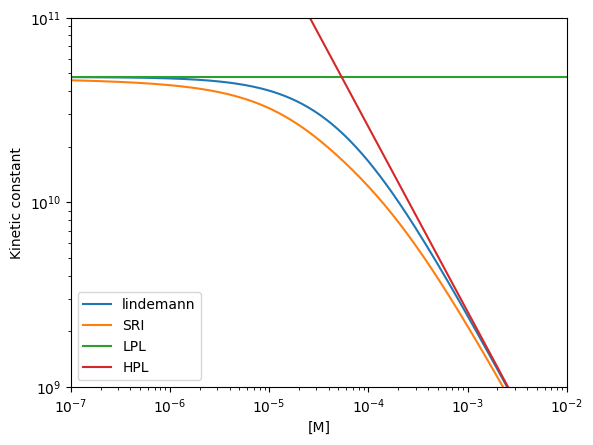

In [6]:
P_range = jnp.logspace(jnp.log10(0.001), jnp.log10(1000), 300)

hpl = rate_constant.hpl.kinetic_constant(jnp.array([1000]*300)) # Compute the value of the HPL
lpl = rate_constant.lpl.kinetic_constant(jnp.array([1000]*300)) # Compute the value of the LPL
k_sri, M = rate_constant.kinetic_constant(1000, P_range) # Kinetic constant here returns also M just to ease subsequent plotting stuff

fig, ax = plt.subplots()
ax.plot(M, k_lindemann, label="lindemann")
ax.plot(M, k_sri, label="SRI")
ax.plot(M, lpl, label="LPL")
ax.plot(M, hpl/M, label="HPL")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1e-7, 0.01])
ax.set_ylim([1e9, 1e11])
ax.set_xlabel("[M]")
ax.set_ylabel("Kinetic constant")
ax.legend()
plt.show()